# Physics: constants, reconstruction, and event displays

Single-file walkthrough of the physics pipeline for atmospheric neutrino events at DUNE.

**What this notebook contains:**

1. Constants (PDG codes, particle masses, detector geometry, wire-plane angles).
2. ROOT → numpy loader.
3. Per-event hit and MC truth extraction.
4. 2D wire-plane displays (W, V, U).
5. Drift binning and 3D space-point reconstruction.
6. Space-point quality filtering.
7. Per-particle direction reconstruction (PCA for tracks, vector averaging for showers).
8. Neutrino kinematics: momentum sum, zenith angle, baseline `L`.
9. 3D event displays.

Each unique neutrino interaction is called an **instance**: it begins where `parent_id == -1` appears in the MC file. There are ~9,700 instances across 100 unique physics event templates (event_id 0–99).

## 1. Imports & constants

In [1]:
import math
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D  # noqa
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (8, 5)

# ----- PDG codes -----
NEUTRINO_PDGS       = {12, -12, 14, -14, 16, -16}
CHARGED_LEPTON_PDGS = {11, -11, 13, -13, 15, -15}
PROTON_PDG          = 2212
SHOWER_PDGS         = {11, -11, 22}        # treat as showers (PCA fails on these)

PDG_NAME = {
    11: 'e-', -11: 'e+',
    12: 'nu_e', -12: 'nu_e_bar',
    13: 'mu-', -13: 'mu+',
    14: 'nu_mu', -14: 'nu_mu_bar',
    15: 'tau-', -15: 'tau+',
    16: 'nu_tau', -16: 'nu_tau_bar',
    22: 'gamma',
    211: 'pi+', -211: 'pi-',
    2212: 'p', -2212: 'pbar',
    2112: 'n', -2112: 'nbar',
}

# Rest masses (GeV)
PARTICLE_MASSES = {
    11: 0.000511, 13: 0.105658, 15: 1.77686,
    22: 0.0,
    211: 0.13957, 2212: 0.938272, 2112: 0.939565,
}

# ----- DUNE Horizontal-Drift workspace geometry (cm) -----
TPC_BOUNDS = dict(x_min=-362.6625, x_max=362.6625,
                  y_min=-603.924,  y_max=603.924,
                  z_min=-0.876,    z_max=1393.464)
APA_X         = (-3.2475, 3.2475)
CATHODE_X     = (-362.6625, 362.6625)

# ----- Wire-plane angles (radians) -----
THETA_U, THETA_V, THETA_W = +0.623257100582, -0.623257100582, 0.0
COS_U, SIN_U = np.cos(THETA_U), np.sin(THETA_U)
COS_V, SIN_V = np.cos(THETA_V), np.sin(THETA_V)
COS_W, SIN_W = np.cos(THETA_W), np.sin(THETA_W)
SIN_DVU = np.sin(THETA_V - THETA_U)
SIN_DWV = np.sin(THETA_W - THETA_V)
SIN_DUW = np.sin(THETA_U - THETA_W)

# ----- Earth geometry for atmospheric baseline L -----
EARTH_RADIUS_KM = 6371.0
ATMOS_PROD_HEIGHT_KM = 15.0
DETECTOR_DEPTH_KM = 1.5

# ----- Reconstruction tunables -----
DRIFT_BIN_WIDTH_CM   = 0.5
LINE_FIT_DIST_CM     = 2.0
MIN_POINTS_FOR_LINE  = 3
MIN_HITS_DIRECTION   = 3
MAX_RAW_3D_POINTS    = 15_000   # skip pathologically busy events

print('Constants loaded.')

Constants loaded.


## 2. Wire ↔ (y, z) transformations

In [2]:
# Wire-pair --> (y, z)
def uw_to_y(u, w): return (w * COS_U - u * COS_W) / SIN_DUW
def uw_to_z(u, w): return (w * SIN_U - u * SIN_W) / SIN_DUW
def vw_to_y(v, w): return (v * COS_W - w * COS_V) / SIN_DWV
def vw_to_z(v, w): return (v * SIN_W - w * SIN_V) / SIN_DWV

# (y, z) --> wire (used for residual checks)
def yz_to_u(y, z): return z * COS_U - y * SIN_U
def yz_to_v(y, z): return z * COS_V - y * SIN_V
def yz_to_w(y, z): return z * COS_W - y * SIN_W

## 3. Load ROOT files

**Important data structure detail:**

* The hits file has 9,700 rows -- one per interaction instance.
* The MC file has ~372k rows -- many MC particles per instance.
* `event_id` cycles through 0–99 (only 100 unique physics templates), but each value reappears ~97 times.
* The unique key for one neutrino interaction is the **row index** in the hits file (or equivalently, the position in the MC file at which `parent_id == -1` appears).

We use the hits-row index as our `instance_id` everywhere downstream.

In [3]:
MC_PATH   = 'mc_0.root'
HITS_PATH = 'hits_0.root'

mc_branches = ['event_id','mc_id','pdg','energy','visible_energy',
               'mom_vec','vtx_vec','parent_id','n_hits_total']
hit_branches = ['event_id','plane','mc_id','drift','channel','adc','width']

def load_root(path, tree, branches):
    """ROOT -> dict of numpy arrays."""
    out = {}
    with uproot.open(f'{path}:{tree}') as t:
        for b in branches:
            out[b] = t[b].array(library='np')
    return out

mc   = load_root(MC_PATH,   'mc',   mc_branches)
hits = load_root(HITS_PATH, 'hits', hit_branches)

n_instances = len(hits['event_id'])
print(f'Loaded {n_instances:,} hit instances and {len(mc["mc_id"]):,} MC particle rows.')

Loaded 9,700 hit instances and 372,488 MC particle rows.


## 4. Slice MC truth per instance

Each instance is a contiguous block of MC rows starting at a row where `parent_id == -1` (the incoming neutrino). We pre-compute the start/end positions once.

In [4]:
instance_starts = np.where(mc['parent_id'] == -1)[0]
instance_ends   = np.append(instance_starts[1:], len(mc['parent_id']))
print(f'Total MC instances: {len(instance_starts):,}  (matches hits rows: {n_instances == len(instance_starts)})')

def mc_slice(instance_id):
    """Return a dict of MC arrays sliced to this single instance."""
    s, e = instance_starts[instance_id], instance_ends[instance_id]
    return {k: v[s:e] for k, v in mc.items()}

Total MC instances: 9,700  (matches hits rows: True)


## 5. Pick an event and pull its hits

In [5]:
INSTANCE = 0

plane    = hits['plane'][INSTANCE]
drift    = hits['drift'][INSTANCE]
adc      = hits['adc'][INSTANCE]
channel  = hits['channel'][INSTANCE]
hit_mc   = hits['mc_id'][INSTANCE]

print(f'Instance {INSTANCE}: {len(plane):,} hits')
print(f'  unique mc_ids in hits: {np.unique(hit_mc)}')
print(f'  drift range: [{drift.min():.1f}, {drift.max():.1f}] cm')

Instance 0: 102 hits
  unique mc_ids in hits: [1 2 3 4]
  drift range: [150.5, 235.1] cm


## 6. 2D wire-plane displays

What the detector actually records: three projections (W, V, U) of drift coordinate vs wire channel, with charge intensity on the colour scale.

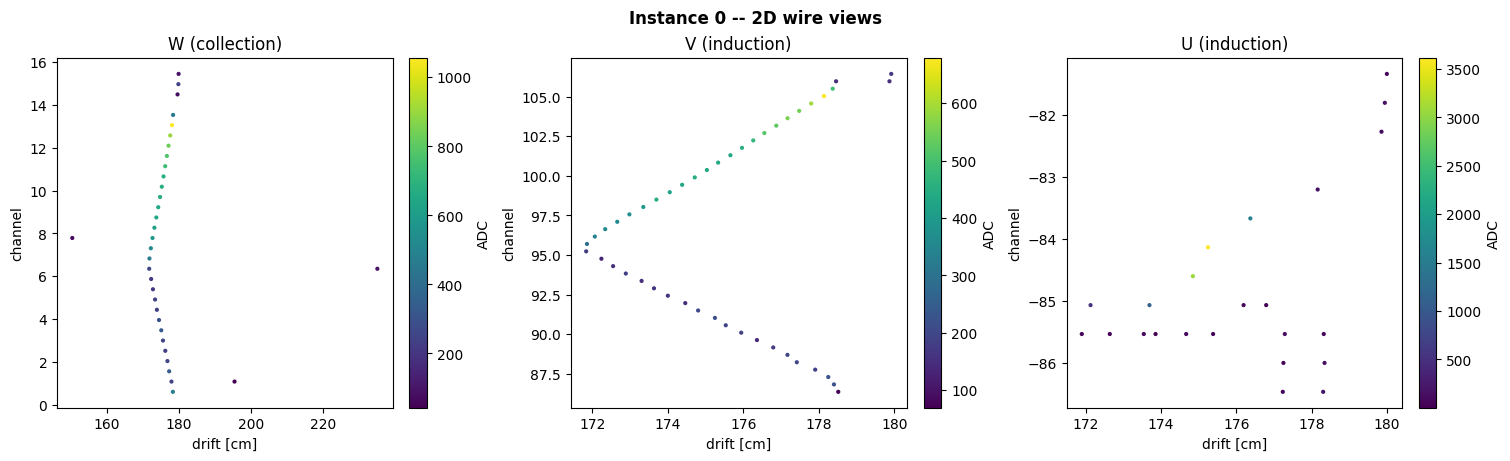

In [6]:
PLANE_NAMES = {0: 'W (collection)', 1: 'V (induction)', 2: 'U (induction)'}

def plot_2d_views(plane, drift, channel, adc, title=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
    for ax, pid in zip(axes, [0, 1, 2]):
        m = plane == pid
        sc = ax.scatter(drift[m], channel[m], c=adc[m], s=4, cmap='viridis')
        fig.colorbar(sc, ax=ax, label='ADC')
        ax.set_title(PLANE_NAMES[pid])
        ax.set_xlabel('drift [cm]'); ax.set_ylabel('channel')
    if title: fig.suptitle(title, fontweight='bold')
    return fig

plot_2d_views(plane, drift, channel, adc, title=f'Instance {INSTANCE} -- 2D wire views');

## 7. Drift binning + 3D space-point reconstruction

In [7]:
def group_drifts(drift_array, tolerance=DRIFT_BIN_WIDTH_CM):
    """Group sorted drift values into bins of width tolerance."""
    if len(drift_array) == 0:
        return []
    sorted_d = np.sort(drift_array)
    groups = [[float(sorted_d[0])]]
    for d in sorted_d[1:]:
        if d - groups[-1][0] <= tolerance:
            groups[-1].append(float(d))
        else:
            groups.append([float(d)])
    return groups

def reconstruct_space_points(plane, drift, adc, channel, mc_id):
    """
    For each (drift slice, mc_id), combine wire-plane hits into 3D points.
    For every W hit, try every U/W and V/W pair in the same slice/particle.
    Returns coords (N,3), adc (N,), mc_ids (N,), residuals (N,2), transforms (N,)
    """
    groups = group_drifts(drift)
    coords, adc_out, mc_out, res_out, tf_out = [], [], [], [], []
    for bin_d in groups:
        x_avg = float(np.mean(bin_d))
        bin_mask = (drift >= bin_d[0]) & (drift <= bin_d[-1])
        for mid in np.unique(mc_id[bin_mask]):
            sel = bin_mask & (mc_id == mid)
            u_idx = np.where(sel & (plane == 2))[0]
            v_idx = np.where(sel & (plane == 1))[0]
            w_idx = np.where(sel & (plane == 0))[0]
            if len(w_idx) == 0:
                continue
            for wi in w_idx:
                wc, wa = channel[wi], adc[wi]
                if len(u_idx) > 0 and len(v_idx) > 0:
                    for ui in u_idx:
                        uc = channel[ui]
                        y, z = uw_to_y(uc, wc), uw_to_z(uc, wc)
                        v_res = min(abs(yz_to_v(y, z) - channel[vh]) for vh in v_idx)
                        coords.append((x_avg, y, z)); adc_out.append(wa)
                        mc_out.append(int(mid)); res_out.append((np.nan, v_res)); tf_out.append('uw')
                    for vi in v_idx:
                        vc = channel[vi]
                        y, z = vw_to_y(vc, wc), vw_to_z(vc, wc)
                        u_res = min(abs(yz_to_u(y, z) - channel[uh]) for uh in u_idx)
                        coords.append((x_avg, y, z)); adc_out.append(wa)
                        mc_out.append(int(mid)); res_out.append((u_res, np.nan)); tf_out.append('vw')
                elif len(u_idx) > 0:
                    for ui in u_idx:
                        uc = channel[ui]
                        coords.append((x_avg, uw_to_y(uc, wc), uw_to_z(uc, wc)))
                        adc_out.append(wa); mc_out.append(int(mid))
                        res_out.append((np.nan, np.nan)); tf_out.append('uw_only')
                elif len(v_idx) > 0:
                    for vi in v_idx:
                        vc = channel[vi]
                        coords.append((x_avg, vw_to_y(vc, wc), vw_to_z(vc, wc)))
                        adc_out.append(wa); mc_out.append(int(mid))
                        res_out.append((np.nan, np.nan)); tf_out.append('vw_only')
    return (np.asarray(coords).reshape(-1, 3),
            np.asarray(adc_out), np.asarray(mc_out, dtype=int),
            np.asarray(res_out).reshape(-1, 2), np.asarray(tf_out))

coords, adc3d, mc3d, residuals, transforms = reconstruct_space_points(plane, drift, adc, channel, hit_mc)
print(f'Raw 3D points: {len(coords):,}')

Raw 3D points: 96


## 8. Filter 3D points by residual + line-fit proximity

In [8]:
def fit_3d_line(points):
    """PCA / SVD line fit: returns (centroid, unit_direction)."""
    if len(points) < 2: return None, None
    centroid = np.mean(points, axis=0)
    _, _, vh = np.linalg.svd(points - centroid, full_matrices=False)
    return centroid, vh[0]

def point_to_line_distance(p, lp, ld):
    vec = p - lp
    return float(np.linalg.norm(vec - np.dot(vec, ld) * ld))

def filter_space_points(coords, adc, mc_ids, residuals, distance_threshold=LINE_FIT_DIST_CM,
                        min_points=MIN_POINTS_FOR_LINE):
    n = len(coords)
    if n == 0:
        return coords, adc, mc_ids, residuals, 1.0
    flat = residuals.flatten(); valid = flat[~np.isnan(flat)]
    rms = float(np.sqrt(np.mean(valid**2))) if len(valid) > 0 else 1.0
    good = np.zeros(n, dtype=bool); no_res = np.zeros(n, dtype=bool)
    for i in range(n):
        u, v = residuals[i]
        hu, hv = not np.isnan(u), not np.isnan(v)
        if hu and hv:   good[i] = (u < rms) and (v < rms)
        elif hu:        good[i] = u < rms
        elif hv:        good[i] = v < rms
        else:           no_res[i] = True
    fitted = {}; pdist = np.full(n, np.nan)
    for mid in np.unique(mc_ids):
        m = mc_ids == mid
        trusted = coords[m & good]
        if len(trusted) >= min_points:
            lp, ld = fit_3d_line(trusted)
            fitted[int(mid)] = (lp, ld)
            for i in np.where(m)[0]:
                pdist[i] = point_to_line_distance(coords[i], lp, ld)
    final = good.copy()
    for i in np.where(no_res)[0]:
        mid = int(mc_ids[i])
        final[i] = (pdist[i] < distance_threshold) if mid in fitted else True
    return coords[final], adc[final], mc_ids[final], residuals[final], rms

coords_f, adc_f, mc3d_f, residuals_f, rms = filter_space_points(coords, adc3d, mc3d, residuals)
print(f'Filtered: {len(coords_f):,} / {len(coords):,}  (RMS threshold = {rms:.3f} cm)')

Filtered: 68 / 96  (RMS threshold = 0.575 cm)


## 9. Build per-instance MC truth and find primaries

In [9]:
def build_particles(mc_ev, hit_mc_ids):
    """Convert one instance's MC arrays into a list of particle dicts."""
    hit_set = set(np.unique(hit_mc_ids).tolist())
    pdg2pdg = dict(zip(mc_ev['mc_id'].tolist(), mc_ev['pdg'].tolist()))
    out = []
    for i in range(len(mc_ev['mc_id'])):
        parent_id = int(mc_ev['parent_id'][i])
        parent_pdg = int(pdg2pdg.get(parent_id, 0)) if parent_id != -1 else None
        mom = np.asarray(mc_ev['mom_vec'][i], dtype=float)
        vtx = np.asarray(mc_ev['vtx_vec'][i], dtype=float)
        out.append({
            'mc_id': int(mc_ev['mc_id'][i]),
            'pdg': int(mc_ev['pdg'][i]),
            'name': PDG_NAME.get(int(mc_ev['pdg'][i]), f'PDG_{int(mc_ev["pdg"][i])}'),
            'energy': float(mc_ev['energy'][i]),
            'visible_energy': float(mc_ev['visible_energy'][i]),
            'mom_x': float(mom[0]), 'mom_y': float(mom[1]), 'mom_z': float(mom[2]),
            'momentum_mag': float(np.linalg.norm(mom)),
            'vtx_x': float(vtx[0]), 'vtx_y': float(vtx[1]), 'vtx_z': float(vtx[2]),
            'parent_id': parent_id, 'parent_pdg': parent_pdg,
            'has_hits': int(mc_ev['mc_id'][i]) in hit_set,
        })
    return out

def find_parent_neutrino(particles):
    for p in particles:
        if p['parent_id'] == -1 and abs(p['pdg']) in NEUTRINO_PDGS:
            return p
    return None

def find_primaries(particles, parent_nu):
    if parent_nu is None: return []
    return [p for p in particles if p['parent_id'] == parent_nu['mc_id']]

particles = build_particles(mc_slice(INSTANCE), hit_mc)
parent_nu = find_parent_neutrino(particles)
primaries = find_primaries(particles, parent_nu)

print(f"Parent neutrino: {parent_nu['name']} (E={parent_nu['energy']:.3f} GeV)")
print(f"\nPrimaries (final-state particles at vertex):")
for p in primaries:
    print(f"  mc_id={p['mc_id']:<3} {p['name']:<6} E={p['energy']:.3f} GeV  has_hits={p['has_hits']}")

is_cc = any(abs(p['pdg']) in CHARGED_LEPTON_PDGS for p in primaries)
print(f"\nThis instance is: {'CC' if is_cc else 'NC'}")

Parent neutrino: nu_e (E=1.015 GeV)

Primaries (final-state particles at vertex):
  mc_id=3   p      E=1.069 GeV  has_hits=True
  mc_id=4   e-     E=0.681 GeV  has_hits=True

This instance is: CC


## 10. Per-particle direction reconstruction

* Track-like (everything except `e±`, `γ`): PCA on vertex-centred 3D points.
* Shower-like (`e±`, `γ`): weighted vector average (PCA biases towards the longest shower axis, not the initial direction).

In [10]:
def reconstruct_directions(primaries, coords_f, mc_ids_f):
    out = {}
    for p in primaries:
        if not p['has_hits']:
            continue
        mid = p['mc_id']; pdg_abs = abs(p['pdg'])
        track = coords_f[mc_ids_f == mid]
        if len(track) < MIN_HITS_DIRECTION:
            continue
        vertex = np.array([p['vtx_x'], p['vtx_y'], p['vtx_z']])
        centred = track - vertex
        if pdg_abs in SHOWER_PDGS:
            norms = np.linalg.norm(centred, axis=1, keepdims=True)
            unit = np.divide(centred, norms, out=np.zeros_like(centred), where=norms > 0)
            w = norms.squeeze() / norms.sum()
            d = np.average(unit, axis=0, weights=w)
            n = np.linalg.norm(d)
            if n == 0: continue
            d /= n; method = 'vector_avg'
        else:
            pca = PCA(n_components=3); pca.fit(centred)
            d = pca.components_[0]; method = 'pca'
        # Sign: must point away from vertex on average
        furthest = centred[np.argmax(np.linalg.norm(centred, axis=1))]
        if np.dot(d, furthest) < 0: d = -d
        out[mid] = {'direction': d, 'method': method, 'pdg': p['pdg']}
    return out

directions = reconstruct_directions(primaries, coords_f, mc3d_f)
for mid, info in directions.items():
    d = info['direction']
    print(f"mc_id={mid:<3} {PDG_NAME.get(info['pdg'])}: method={info['method']}  "
          f"dir=({d[0]:+.3f}, {d[1]:+.3f}, {d[2]:+.3f})")

mc_id=3   p: method=pca  dir=(+0.549, +0.608, +0.574)
mc_id=4   e-: method=vector_avg  dir=(+0.618, -0.582, -0.529)


## 11. Neutrino kinematics: momentum sum, zenith, baseline `L`

In [11]:
def reconstruct_neutrino(primaries, directions, parent_nu):
    """Sum primary momenta (truth |p|, reco direction)."""
    if parent_nu is None: return None
    vertex = np.array([parent_nu['vtx_x'], parent_nu['vtx_y'], parent_nu['vtx_z']])
    p_total = np.zeros(3); particle_info = []
    for p in primaries:
        if p['mc_id'] not in directions or not p['has_hits']:
            particle_info.append({'mc_id': p['mc_id'], 'name': p['name'], 'reconstructed': False})
            continue
        mass = PARTICLE_MASSES.get(abs(p['pdg']), 0.0)
        E = p['energy']; pmag = float(np.sqrt(max(E*E - mass*mass, 0.0)))
        pvec = pmag * directions[p['mc_id']]['direction']
        p_total += pvec
        particle_info.append({
            'mc_id': p['mc_id'], 'name': p['name'],
            'reco_p_mag': pmag, 'reco_p_vec': pvec,
            'true_p_mag': p['momentum_mag'], 'reconstructed': True,
            'reco_direction': directions[p['mc_id']]['direction'],
        })
    p_mag_total = float(np.linalg.norm(p_total))
    direction = p_total / p_mag_total if p_mag_total > 0 else np.zeros(3)
    return {'vertex': vertex, 'momentum_vector': p_total, 'momentum_mag': p_mag_total,
            'direction': direction, 'energy': p_mag_total, 'particles': particle_info}

def zenith_angle_deg(direction):
    """theta_z=0 -> straight down; theta_z=180 -> straight up through Earth."""
    n = np.linalg.norm(direction)
    if n == 0: return float('nan')
    cos_z = max(-1.0, min(1.0, -float(direction[1])/n))
    return float(np.degrees(np.arccos(cos_z)))

def baseline_km(zenith_rad,
                production_height=ATMOS_PROD_HEIGHT_KM,
                detector_depth=DETECTOR_DEPTH_KM,
                R=EARTH_RADIUS_KM):
    """Spherical-Earth law of cosines."""
    if not np.isfinite(zenith_rad): return float('nan')
    a = R - detector_depth   # detector radius from Earth's centre
    b = R + production_height
    cos_z = np.cos(zenith_rad)
    disc = a*a*cos_z*cos_z + (b*b - a*a)
    if disc < 0: return float('nan')
    return float(-a*cos_z + np.sqrt(disc))

nu = reconstruct_neutrino(primaries, directions, parent_nu)
if nu is not None and nu['momentum_mag'] > 0:
    zen_deg = zenith_angle_deg(nu['direction'])
    L = baseline_km(np.radians(zen_deg))
    print(f"Reconstructed neutrino:")
    print(f"  vertex     = {nu['vertex']}")
    print(f"  E          = {nu['energy']:.3f} GeV")
    print(f"  direction  = ({nu['direction'][0]:+.3f}, {nu['direction'][1]:+.3f}, {nu['direction'][2]:+.3f})")
    print(f"  zenith     = {zen_deg:.1f} deg")
    print(f"  baseline L = {L:,.0f} km")
    print(f"\nTruth: nu E = {parent_nu['energy']:.3f} GeV")

Reconstructed neutrino:
  vertex     = [171.64770508 154.50469971   6.52225113]
  E          = 0.709 GeV
  direction  = (+0.988, -0.120, -0.093)
  zenith     = 83.1 deg
  baseline L = 127 km

Truth: nu E = 1.015 GeV


## 12. 3D event displays

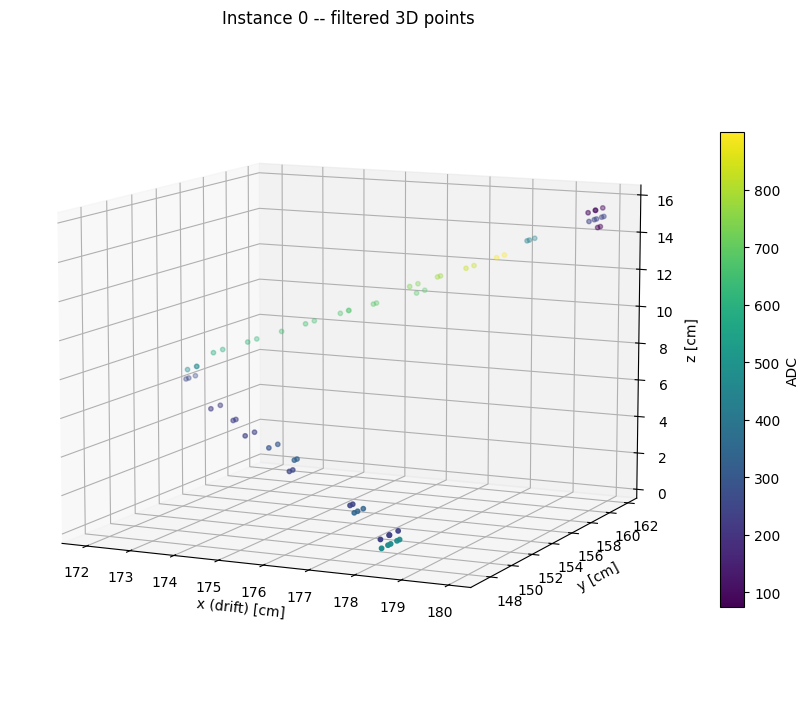

In [14]:
def add_detector_outline(ax):
    ymin, ymax = TPC_BOUNDS['y_min'], TPC_BOUNDS['y_max']
    zmin, zmax = TPC_BOUNDS['z_min'], TPC_BOUNDS['z_max']
    for x in CATHODE_X:
        ax.plot([x]*2, [ymin, ymax], [zmin, zmin], 'k--', lw=0.5, alpha=0.4)
        ax.plot([x]*2, [ymin, ymax], [zmax, zmax], 'k--', lw=0.5, alpha=0.4)
    for x in APA_X:
        ax.plot([x]*2, [ymin, ymax], [zmin, zmin], 'r--', lw=0.5, alpha=0.4)
        ax.plot([x]*2, [ymin, ymax], [zmax, zmax], 'r--', lw=0.5, alpha=0.4)

# All filtered 3D points coloured by ADC
fig = plt.figure(figsize=(8, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(coords_f[:,0], coords_f[:,1], coords_f[:,2], c=adc_f, s=10, cmap='viridis')
fig.colorbar(sc, label='ADC', shrink=0.6)
# add_detector_outline(ax) - to add detector boundaries
ax.set_xlabel('x (drift) [cm]'); ax.set_ylabel('y [cm]'); ax.set_zlabel('z [cm]')
ax.view_init(elev=10, azim=-65)
ax.set_title(f'Instance {INSTANCE} -- filtered 3D points');

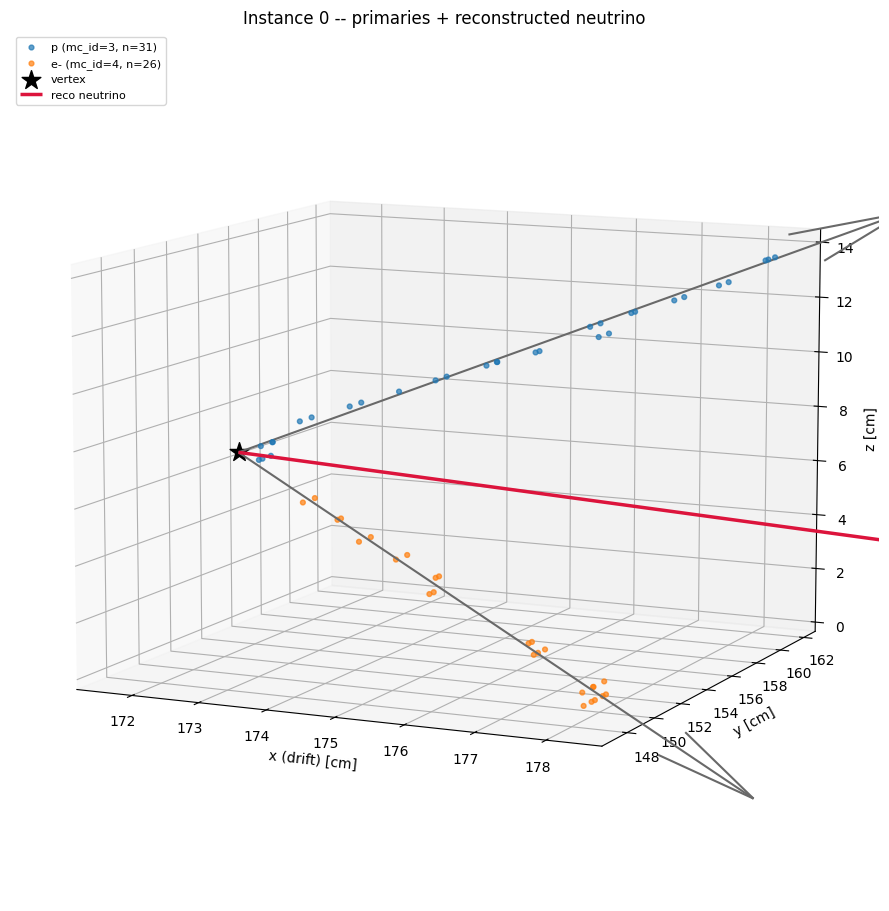

In [17]:
# Primaries-only 3D display, coloured per particle, with reconstructed direction arrows and the summed neutrino arrow
primary_ids = {p['mc_id'] for p in primaries}
keep = np.isin(mc3d_f, list(primary_ids))
coords_p = coords_f[keep]; mc_ids_p = mc3d_f[keep]
pdg_lookup = {p['mc_id']: p['pdg'] for p in primaries}

fig = plt.figure(figsize=(9, 9), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, mid in enumerate(np.unique(mc_ids_p)):
    pts = coords_p[mc_ids_p == mid]
    label = f"{PDG_NAME.get(pdg_lookup.get(mid, 0))} (mc_id={mid}, n={len(pts)})"
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], color=colours[i % len(colours)],
               s=12, alpha=0.7, label=label)

if nu is not None:
    v = nu['vertex']
    ax.scatter([v[0]], [v[1]], [v[2]], marker='*', color='black', s=200, label='vertex', zorder=10)
    # Per-primary reco arrows
    for mid, info in directions.items():
        d = info['direction'] * 15.0
        ax.quiver(v[0], v[1], v[2], d[0], d[1], d[2],
                  arrow_length_ratio=0.15, color='dimgrey', lw=1.5)
    # Summed neutrino direction
    nu_d = nu['direction'] * 60.0
    ax.quiver(v[0], v[1], v[2], nu_d[0], nu_d[1], nu_d[2],
              arrow_length_ratio=0.2, color='crimson', lw=2.5, label='reco neutrino')

# add_detector_outline(ax)
ax.set_xlabel('x (drift) [cm]'); ax.set_ylabel('y [cm]'); ax.set_zlabel('z [cm]')
ax.set_title(f'Instance {INSTANCE} -- primaries + reconstructed neutrino')
ax.view_init(elev=10, azim=-65)
ax.legend(loc='upper left', fontsize=8);

## Summary

All physics primitives are now defined as ordinary functions (no globals), each takes its inputs explicitly and returns its outputs explicitly. Notebook 02 reuses these functions in a loop over all 9,700 instances to produce the tabular dataset.